In [1]:
import xpress as xp
import numpy as np 
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
def change_name(name):
    n = len(name)
    a = name[:(n-7)//2]
    #print(a)
    b = name[(n-7)//2 + 2:]
    #print(b)
    c = name[:(n-7)//2 +5]
    d = name[(n-7)//2 +5+2:]
    if '(UG)' in a:
        return a
    elif '(UG)' in b:
        return b
    elif '(UG)' in c:
        return c
    elif '(UG)' in c:
        return d
    else:
        split = name.split(',')
        a = split[0]
        b = split[1]
        if '(UG)' in a:
            return a
        elif '(UG)' in b:
            return b
        else:
            return "Error"
departments_needed = ['School of Mathematics','School of Philosophy, Psychology and Language Sciences','School of Economics','School of Informatics',
                      # 'School of Physics and Astronomy',
                      'Business School']
collections_needed = ['Economics Course Options for Joint Programmes Year 3 (A)',
       'Economics Course Options Year 3 (joint programmes)',
       'Economics and Maths Dissertation',
       'Economics Course Options Year 4 (joint programmes)',
       'Topics in Microeconomics', 'Essentials of Econometrics',#'MathPhy : Mathematics Projects',
       # 'MathsPhysics : Y4 Physics Projects',
       # 'Undergraduate (School of Physics and Astronomy) Level 10 and 11 courses',
       # 'Electromagnetism and Relativity',
       # 'MathsPhysics : Y3 physics choice',
       # 'Undergraduate (School of Physics and Astronomy) Level 9 and 10  courses',
       'MathsBusiness : Y4 Projects',
       '2024-25: UTMATHB : Y4/5 : Approved Outside Courses',
       'ROU_H_UT International Business 4_10',
       'Strategic Management',
       '2024-25: UTMATHB : Y3 options : Business options',
       'Informatics Hons 3rd Year Group Project and Large Practical',
       'Informatics Hons 3rd Year AI Courses',
       'Informatics Hons 3rd Year Joint Degree CS Courses',
       'Informatics - Professional Issues',
       'Honours Project (Informatics)',
       'Informatics Hons 4th Year Courses',
        'Year 3 Philosophy - History of Philosophy',
       'Practical Philosophy', 'Theoretical Philosophy',
       'Philosophy Honours Year 4']
programmes_needed = ['Mathematics and Business BSc (Hons)',
                     # 'Mathematics and Physics (BSc Hons)',
                     'Economics and Mathematics (MA Hons)','Computer Science and Mathematics (BSc Hons)',
              'Philosophy and Mathematics (MA Hons)']
courses_df = pd.read_csv("2024-5 Event Module Room.csv")
courses_df = courses_df[courses_df["Module Department"].isin(departments_needed)]
courses_df = courses_df[courses_df["Event Type"]=="Lecture"]
programme_df = pd.read_csv('2024-5 DPT Data.csv',encoding = "latin1")

programme_df = programme_df[programme_df["Programme Year"].isin([3])]
programme_df = programme_df[programme_df["Programme Name"].isin(programmes_needed)]
programme_df = programme_df[programme_df["Collection Name"].isin(collections_needed)]

ug_indices = courses_df[
    (courses_df["Module Department"]=="School of Informatics") & 
    (courses_df['Module Name'].str.contains('\(UG\)', na=False))
].index

# Apply the change_name function to those specific rows
courses_df.loc[ug_indices, 'Module Name'] = courses_df.loc[ug_indices, 'Module Name'].apply(change_name)
#programme_df = programme_df[programme_df['Collection Reg Group']!="Physics 3 A"]

In [3]:
# Year 3
#Informatics 
condition_inf_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme School Name'] == 'School of Informatics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_inf_A3, 'Collection Reg Group'] = 'School of Informatics 3 A'

#Economics
condition_eco_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme School Name'] == 'School of Economics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_eco_A3, 'Collection Reg Group'] = 'Economics 3 A'

#Philosophy
condition_phi_B3 = (
    (programme_df['Collection Reg Group'] == 'B') & 
    (programme_df['Programme School Name'] == 'School of Philosophy, Psychology and Language Sciences') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_phi_B3, 'Collection Reg Group'] = 'Philosophy 3 B'

#Business
condition_bus_B3 = (
    (programme_df['Collection Reg Group'] == 'B') & 
    (programme_df['Programme Name'] == 'Mathematics and Business BSc (Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bus_B3, 'Collection Reg Group'] = 'Business 3 B'

#Physics
condition_phy_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme Name'] == 'Mathematics and Physics (BSc Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_phy_A3, 'Collection Reg Group'] = 'Physics 3 A'




In [4]:
#Physics
condition_bounds_phy_A3 = (
    (programme_df['Collection Reg Group'] == 'Physics 3 A') & 
    (programme_df['Programme Name'] == 'Mathematics and Physics (BSc Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_phy_A3, 'Collection Group Min'] = 20.0
programme_df.loc[condition_bounds_phy_A3, 'Collection Group Max'] = 40.0

#Business
condition_bounds_bus_B3 = (
    (programme_df['Collection Reg Group'] == 'Business 3 B') & 
    (programme_df['Programme Name'] == 'Mathematics and Business BSc (Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_bus_B3, 'Collection Group Min'] = 0.0
programme_df.loc[condition_bounds_bus_B3, 'Collection Group Max'] = 60.0

#Philosophy
condition_bounds_phi_B3 = (
    (programme_df['Collection Reg Group'] == 'Philosophy 3 B') & 
    (programme_df['Programme School Name'] == 'School of Philosophy, Psychology and Language Sciences') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_phi_B3, 'Collection Group Min'] = 40.0
programme_df.loc[condition_bounds_phi_B3, 'Collection Group Max'] = 80.0

#Economics
condition_bounds_eco_A3 = (
    (programme_df['Collection Reg Group'] == 'Economics 3 A') & 
    (programme_df['Programme School Name'] == 'School of Economics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_eco_A3, 'Collection Group Min'] = 0.0
programme_df.loc[condition_bounds_eco_A3, 'Collection Group Max'] = 20.0



In [5]:
def extract_programme_structure(programme_df):
    """
    Extract programme-specific information including collections and regression groups
    Returns a dictionary structure with collections and regression groups as dictionaries
    """
    # Get unique programmes
    programmes = programme_df['Programme Name'].unique().tolist()
    
    programme_data = {}
    
    for programme in programmes:
        prog_data = programme_df[programme_df['Programme Name'] == programme]
        
        # Get compulsory and optional courses for this programme
        compulsory_courses = prog_data[
            prog_data['Compulsory/Optional'] == 'Compulsory'
        ]['Course Name'].unique().tolist()
        
        optional_courses = prog_data[
            prog_data['Compulsory/Optional'] == 'Optional'
        ]['Course Name'].unique().tolist()
        
        # Get all courses for this programme
        all_courses = prog_data['Course Name'].unique().tolist()
        
        # Get collection information - store as dictionary
        collections = {}
        for _, row in prog_data.iterrows():
            collection_code = row.get('Collection Code')
            if pd.notna(collection_code) and collection_code != '':
                if collection_code not in collections:
                    collections[collection_code] = {
                        'name': row.get('Collection Name', ''),
                        'min_value': row.get('Collection Min Value', 0),
                        'max_value': row.get('Collection Max Value', 999),
                        'reg_group': row.get('Collection Reg Group', ''),
                        'courses': []
                    }
                # Add course to collection if not already there
                if row['Course Name'] not in collections[collection_code]['courses']:
                    collections[collection_code]['courses'].append(row['Course Name'])
        
        # Get regression group information - store as dictionary
        regression_groups = {}
        for _, row in prog_data.iterrows():
            reg_group = row.get('Collection Reg Group')
            if pd.notna(reg_group) and reg_group != '':
                if reg_group not in regression_groups:
                    regression_groups[reg_group] = {
                        'min_value': row.get('Collection Group Min', 0),
                        'max_value': row.get('Collection Group Max', 999),
                        'collections': []
                    }
                # Add collection to regression group if not already there
                collection_code = row.get('Collection Code')
                if pd.notna(collection_code) and collection_code != '':
                    if collection_code not in regression_groups[reg_group]['collections']:
                        regression_groups[reg_group]['collections'].append(collection_code)
        
        programme_data[programme] = {
            'compulsory_courses': compulsory_courses,
            'optional_courses': optional_courses,
            'all_courses': all_courses,
            'collections': collections,
            'regression_groups': regression_groups
        }
    
    return programme_data
programme_data = extract_programme_structure(programme_df)
#programme_data

In [6]:


def extract_timetable_info(courses_df, programmes_data):
    """
    Extract v parameter with dynamic duration per course
    """
    # Filter for all relevant courses
    all_relevant_courses = {"G1","G2","G3","G4",'G5','G6','G7','G8','O1','O2','O3','O4'}
    
    for programme in programmes_data:
        all_relevant_courses.update(programmes_data[programme]['compulsory_courses'])
        all_relevant_courses.update(programmes_data[programme]['optional_courses'])
    
    # Filter timetable data for relevant courses
    relevant_schedule = courses_df[courses_df['Module Name'].isin(all_relevant_courses)].copy()
    
    # Parse timeslot (format: "Monday 10:00")
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    # Parse weeks (format like "1-11,13-24")
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to integers
    day_map = {
        'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 
        'Friday': 5, 'Saturday': 6, 'Sunday': 7,
        'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7
    }
    
    # Create v parameter dictionary
    v = {}
    
    # For each course, build a dictionary of its scheduled events with durations
    for course in relevant_schedule['Module Name'].unique():
        course_schedule = relevant_schedule[relevant_schedule['Module Name'] == course]
        
        for _, row in course_schedule.iterrows():
            # Get timeslot
            day, start_hour = parse_timeslot(row['Timeslot'])
            if day is None:
                continue
                
            day_num = day_map.get(day, 0)
            if day_num == 0:
                print(f"Warning: Unknown day format: {day}")
                continue
            
            # Get duration from the Duration column
            duration = row['Duration (minutes)']
            if pd.isna(duration):
                # Fallback: use default based on event type
                event_type = row['Event Type']
                default_durations = {
                    'Lecture': 60,
                    'Workshop': 60,
                    'Tutorial': 60,
                    'Lab': 120,
                    'Seminar': 60
                }
                duration = default_durations.get(event_type, 60)
            
            # Calculate end hour (assuming duration is in minutes)
            # If duration is 60, end_hour = start_hour + 1
            # If duration is 90, end_hour = start_hour + 1.5 (we'll handle half-hours)
            # For simplicity, we'll treat hour slots as discrete and mark all hours covered
            duration_hours = duration / 60
            end_hour_float = start_hour + duration_hours
            
            # Determine which hour slots this event occupies
            # For integer hours, we can use integer hours
            occupied_hours = []
            current_hour = start_hour
            remaining_duration = duration
            
            while remaining_duration > 0:
                occupied_hours.append(current_hour)
                remaining_duration -= 60
                current_hour += 1
            
            # Alternative: if you want to handle half-hour slots more precisely
            # occupied_hours = [h for h in range(start_hour, start_hour + int(np.ceil(duration_hours)))]
            
            # Parse weeks
            weeks = parse_weeks(row['Weeks'])
            
            # Determine semester
            semester = row['Semester']
            if semester not in [1, 2]:
                # If semester is not 1 or 2, try to infer from weeks
                if weeks and max(weeks) <= 26:
                    semester = 1
                elif weeks and min(weeks) >= 27:
                    semester = 2
                else:
                    semester = 1
            
            campus = row['Campus']
            
            # For each week the course runs
            for week in weeks:
                # For each hour slot the course occupies
                for hour in occupied_hours:
                    # For each programme that includes this course
                    for programme in programmes_data:
                        if course in programmes_data[programme]['all_courses']:
                            v[(course, day_num, hour, week, programme, campus)] = 1
                        else:
                            v[(course, day_num, hour, week, programme, campus)] = 0
    
    return v
programmes_data = extract_programme_structure(programme_df)
#extract_timetable_info(courses_df, programmes_data)

In [7]:
def extract_days_hours_from_v(v):
    """
    Extract unique days and hours from v dictionary
    """
    if not v:
        # If v is empty, use default days and hours
        return [1, 2, 3, 4, 5], list(range(9, 18))  # Monday-Friday, 9am-5pm
    
    days = sorted(list(set([key[1] for key in v.keys()])))
    hours = sorted(list(set([key[2] for key in v.keys()])))
    
    # If no days/hours found, use defaults
    if not days:
        days = [1, 2, 3, 4, 5]
    if not hours:
        hours = list(range(9, 18))
    
    return days, hours

# Add this to your extract_all_parameters function
def extract_all_parameters(courses_df, programme_df):
    """
    Complete extraction including days and hours
    """
    
    # Step 1: Define Maths courses
    gateway_courses = ["G1","G2","G3","G4",'G5','G6','G7','G8']
    optional_courses = ['O1','O2','O3','O4']
    
    # Step 2: Extract programme structure
    programme_data = extract_programme_structure(programme_df)
    programmes = list(programme_data.keys())
    
    # Step 3: Extract timetable info
    v = extract_timetable_info(courses_df, programme_data)
    
    # Step 4: Extract days and hours from v
    days, hours = extract_days_hours_from_v(v)

    weeks = list(range(1, 53))  # E = {1, ..., 52}
    weeks_sem1 = list(range(1, 27))  # E_1 = {1, ..., 26}
    weeks_sem2 = list(range(27, 53))  # E_2 = {27, ..., 52}

    campuses = courses_df['Campus'].dropna().unique().tolist()
    
    # Build the complete parameter set
    parameters = {
        # Sets
        'G': gateway_courses,
        'O': optional_courses,
        'S': [1, 2],  # Semesters
        'D': days,    # Days extracted from timetable
        'H': hours,   # Hours extracted from timetable
        'W': [1, 2],  # Week parity
        'Q': programmes,
        'E': weeks,           # All weeks
        'E1': weeks_sem1,     # Semester 1 weeks
        'E2': weeks_sem2,     # Semester 2 weeks
        'K': campuses,        # Campuses
        # Parameters
        'R_g_L': 3,  # Fixed for gateway
        'R_g_W': 1,  # Fixed for gateway
        'R_g_F': 1,  # Fixed for gateway
        'R_o_L': 3,  # Fixed for optional
        'R_o_W': 1,  # Fixed for optional
        'C_g': 4,    # 4 gateway courses per semester
        'C_o': 2,    # 2 optional courses per semester
        'n_q': {programme: 40 for programme in programmes},  # 40 credits outside Maths
        'n_co': {},  # Credits for each course
        'v': v,
        
        # Programme-specific data
        'programme_data': programme_data,
        
        # Collection and regression groups
        'min_CL': {},
        'max_CL': {},
        'min_CR': {},
        'max_CR': {},
        'SC_cl': {},
        'SCL_cr': {}
    }
    
    # Extract credits (same as before)
    all_courses = set(gateway_courses + optional_courses)
    for programme in programmes:
        all_courses.update(programme_data[programme]['all_courses'])
    
    for course in all_courses:
        credit_info = programme_df[programme_df['Course Name'] == course]['SCQF Credits']
        if len(credit_info) > 0:
            credit_value = credit_info.iloc[0]
            if isinstance(credit_value, str):
                import re
                numbers = re.findall(r'\d+\.?\d*', credit_value)
                if numbers:
                    parameters['n_co'][course] = float(numbers[0])
                else:
                    parameters['n_co'][course] = 20.0
            else:
                parameters['n_co'][course] = float(credit_value)
        else:
            parameters['n_co'][course] = 20.0
    
    # Extract collection information
    for programme in programmes:
        prog_collections = programme_data[programme]['collections']
        for cl_id, cl_info in prog_collections.items():
            parameters['min_CL'][cl_id] = cl_info['min_value']
            parameters['max_CL'][cl_id] = cl_info['max_value']
            
            if cl_id not in parameters['SC_cl']:
                parameters['SC_cl'][cl_id] = []
            for course in cl_info['courses']:
                if course not in parameters['SC_cl'][cl_id]:
                    parameters['SC_cl'][cl_id].append(course)
    
    # Extract regression group information
    for programme in programmes:
        prog_reg_groups = programme_data[programme]['regression_groups']
        for rg_id, rg_info in prog_reg_groups.items():
            parameters['min_CR'][rg_id] = rg_info['min_value']
            parameters['max_CR'][rg_id] = rg_info['max_value']
            
            if rg_id not in parameters['SCL_cr']:
                parameters['SCL_cr'][rg_id] = []
            for cl in rg_info['collections']:
                if cl not in parameters['SCL_cr'][rg_id]:
                    parameters['SCL_cr'][rg_id].append(cl)
    
    # Print summary
    print(f"\nExtraction Summary:")
    print(f"  - Gateway courses: {len(parameters['G'])}")
    print(f"  - Optional courses: {len(parameters['O'])}")
    print(f"  - Programmes: {len(parameters['Q'])}")
    print(f"  - Days: {parameters['D']}")
    print(f"  - Hours: {parameters['H']}")
    print(f"  - Weeks: {len(parameters['E'])} (Sem1: {len(parameters['E1'])}, Sem2: {len(parameters['E2'])})")
    print(f"  - Campuses: {parameters['K']}")
    print(f"  - Collections: {len(parameters['SC_cl'])}")
    print(f"  - Regression groups: {len(parameters['SCL_cr'])}")
    print(f"  - Timetable entries: {len(parameters['v'])}")
    print(f"  - Courses with credits: {len(parameters['n_co'])}")
    
    return parameters
parameters = extract_all_parameters(courses_df,programme_df)
#extract_all_parameters(courses_df,programme_df)


Extraction Summary:
  - Gateway courses: 8
  - Optional courses: 4
  - Programmes: 5
  - Days: [1, 2, 3, 4, 5]
  - Hours: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  - Weeks: 52 (Sem1: 26, Sem2: 26)
  - Campuses: ['Central', 'Holyrood', 'Kings Buildings', 'New College', 'Lauriston']
  - Collections: 16
  - Regression groups: 5
  - Timetable entries: 10060
  - Courses with credits: 159


In [8]:
def create_model_data(parameters):
    """
    Convert extracted parameters into model-ready format
    """
    
    # Create mappings for indices
    course_to_idx = {course: idx for idx, course in enumerate(parameters['G'] + parameters['O'])}
    programme_to_idx = {prog: idx for idx, prog in enumerate(parameters['Q'])}
    
    # Create day and hour mappings
    # You'll need to extract actual days and hours from your timetable data
    days = sorted(list(set([key[1] for key in parameters['v'].keys() if len(key) > 1])))
    hours = sorted(list(set([key[2] for key in parameters['v'].keys() if len(key) > 2])))
    
    model_ready = {
        'G': parameters['G'],
        'O': parameters['O'],
        'S': parameters['S'],
        'D': days,
        'H': hours,
        'W': [1, 2],
        'Q': parameters['Q'],
        'E': parameters['E'],      # All weeks
        'E1': parameters['E1'],    # Semester 1 weeks
        'E2': parameters['E2'],    # Semester 2 weeks
        'K': parameters['K'],      # Campuses
        
        'R_g_L': parameters['R_g_L'],
        'R_g_W': parameters['R_g_W'],
        'R_g_F': parameters['R_g_F'],
        'R_o_L': parameters['R_o_L'],
        'R_o_W': parameters['R_o_W'],
        'C_g': parameters['C_g'],
        'C_o': parameters['C_o'],
        
        'min_CL': parameters['min_CL'],
        'max_CL': parameters['max_CL'],
        'min_CR': parameters['min_CR'],
        'max_CR': parameters['max_CR'],
        
        'n_co': parameters['n_co'],
        'n_q': parameters['n_q'],
        
        'CO_CO_q': {prog: parameters['programme_data'][prog]['compulsory_courses'] 
                   for prog in parameters['Q']},
        'CO_OP_q': {prog: parameters['programme_data'][prog]['optional_courses'] 
                   for prog in parameters['Q']},
        'CO_q': {prog: parameters['programme_data'][prog]['all_courses'] 
                for prog in parameters['Q']},
        
        'SC_cl': parameters['SC_cl'],
        'SCL_cr': parameters['SCL_cr'],
        
        'v': parameters['v']
    }
    
    return model_ready

In [9]:
# Extract all parameters
parameters = extract_all_parameters(courses_df, programme_df)

# Convert to model-ready format
model_data = create_model_data(parameters)

# Now you can use model_data to build your Xpress model
print(f"Number of gateway courses: {len(model_data['G'])}")
print(f"Number of optional courses: {len(model_data['O'])}")
print(f"Number of programmes: {len(model_data['Q'])}")
print(f"Collection groups: {len(model_data['SC_cl'])}")
print(f"Regression groups: {len(model_data['SCL_cr'])}")


Extraction Summary:
  - Gateway courses: 8
  - Optional courses: 4
  - Programmes: 5
  - Days: [1, 2, 3, 4, 5]
  - Hours: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  - Weeks: 52 (Sem1: 26, Sem2: 26)
  - Campuses: ['Central', 'Holyrood', 'Kings Buildings', 'New College', 'Lauriston']
  - Collections: 16
  - Regression groups: 5
  - Timetable entries: 10060
  - Courses with credits: 159
Number of gateway courses: 8
Number of optional courses: 4
Number of programmes: 5
Collection groups: 16
Regression groups: 5


In [10]:
def build_model_from_parameters(parameters):
    """
    Build the Xpress model using the extracted parameters
    (includes pathway decisions and constraint naming for debugging)
    """
    # Unpack parameters (same as before)
    G = parameters['G']
    O = parameters['O']
    S = parameters['S']
    D = parameters['D']
    H = parameters['H']
    W = parameters['W']
    Q = parameters['Q']
    E = parameters['E']
    E1 = parameters['E1']
    E2 = parameters['E2']
    K = parameters['K']
    C_g = parameters['C_g']
    C_o = parameters['C_o']
    R_g_L = parameters['R_g_L']
    R_g_W = parameters['R_g_W']
    R_g_F = parameters['R_g_F']
    R_o_L = parameters['R_o_L']
    R_o_W = parameters['R_o_W']
    v = parameters['v']
    programme_data = parameters['programme_data']
    CO_CO_q = {prog: programme_data[prog]['compulsory_courses'] for prog in Q}
    CO_OP_q = {prog: programme_data[prog]['optional_courses'] for prog in Q}
    CO_q = {prog: programme_data[prog]['all_courses'] for prog in Q}
    SC_cl = parameters['SC_cl']
    SCL_cr = parameters['SCL_cr']
    min_CL = parameters['min_CL']
    max_CL = parameters['max_CL']
    min_CR = parameters['min_CR']
    max_CR = parameters['max_CR']
    n_co = parameters['n_co']
    n_q = parameters['n_q']
    
    # Create problem
    p = xp.problem()
    
    # ==================== DECISION VARIABLES ====================
    print("Creating decision variables...")
    
    # Variables (same as before)
    x_L = {}
    x_W = {}
    x_F = {}
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    x_L[(g, d, h, s)] = xp.var(vartype=xp.binary, name=f"xL_{g}_{d}_{h}_{s}")
                    x_W[(g, d, h, s)] = xp.var(vartype=xp.binary, name=f"xW_{g}_{d}_{h}_{s}")
                    for w in W:
                        x_F[(g, d, h, s, w)] = xp.var(vartype=xp.binary, name=f"xF_{g}_{d}_{h}_{s}_{w}")
    
    y_L = {}
    y_W = {}
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    y_L[(o, d, h, s)] = xp.var(vartype=xp.binary, name=f"yL_{o}_{d}_{h}_{s}")
                    y_W[(o, d, h, s)] = xp.var(vartype=xp.binary, name=f"yW_{o}_{d}_{h}_{s}")
    
    z = {(g, s): xp.var(vartype=xp.binary, name=f"z_{g}_{s}") for g in G for s in S}
    w_var = {(o, s): xp.var(vartype=xp.binary, name=f"w_{o}_{s}") for o in O for s in S}
    
    a = {}
    for q in Q:
        for co in CO_q[q]:
            a[(q, co)] = xp.var(vartype=xp.binary, name=f"a_{q}_{co}")
    
    ta = {}
    for g in G:
        for s in S:
            for q in Q:
                ta[(g, s, q)] = xp.var(vartype=xp.binary, name=f"ta_{g}_{s}_{q}")
    
    lin = {}
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    for q in Q:
                        lin[(g, d, h, s, q)] = xp.var(vartype=xp.binary, name=f"lin_{g}_{d}_{h}_{s}_{q}")
    
    all_vars = (list(x_L.values()) + list(x_W.values()) + list(x_F.values()) +
                list(y_L.values()) + list(y_W.values()) +
                list(z.values()) + list(w_var.values()) +
                list(a.values()) + list(ta.values()) + list(lin.values()))
    p.addVariable(all_vars)
    
    # ==================== CONSTRAINTS ====================
    print("Adding constraints...")
    constraint_count = 0
    constraint_list = []   # store (row_index, name) after adding
    
    def add_constraint(expr, name):
        nonlocal constraint_count
        row = p.addConstraint(expr)   # returns row index (int)
        constraint_list.append((row, name))
        constraint_count += 1
    
    # Helper to flatten weeks (same as before)
    def flatten_weeks(week_list):
        if not isinstance(week_list, (list, tuple)):
            return [week_list]
        flat = []
        for item in week_list:
            if isinstance(item, (list, tuple)):
                flat.extend(flatten_weeks(item))
            else:
                flat.append(item)
        return flat
    
    E_flat = flatten_weeks(E)
    E1_flat = flatten_weeks(E1)
    E2_flat = flatten_weeks(E2)
    
    # -------- Existing constraints (with names) --------
    
    # 1. Fortnightly workshops per gateway
    for g in G:
        add_constraint(xp.Sum(x_F[(g, d, h, s, w)] for d in D for h in H for s in S for w in W) == R_g_F,
                       f"Fortnightly_{g}")
    
    # 2. No multiple events per course per slot
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(x_L[(g, d, h, s)] + x_W[(g, d, h, s)] + 
                                   xp.Sum(x_F[(g, d, h, s, w)] for w in W) <= 1,
                                   f"CourseNoClash_G_{g}_{d}_{h}_{s}")
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(y_L[(o, d, h, s)] + y_W[(o, d, h, s)] <= 1,
                                   f"CourseNoClash_O_{o}_{d}_{h}_{s}")
    
    # 3. Global no‑clash per week (for Maths)
    for d in D:
        for h in H:
            for s in S:
                for w in W:
                    add_constraint(
                        xp.Sum(x_L[(g, d, h, s)] + x_W[(g, d, h, s)] for g in G) +
                        xp.Sum(y_L[(o, d, h, s)] + y_W[(o, d, h, s)] for o in O) +
                        xp.Sum(x_F[(g, d, h, s, w)] for g in G) <= 1,
                        f"GlobalNoClash_{d}_{h}_{s}_{w}")
    
    # 4. Events limited to assigned semester
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(x_L[(g, d, h, s)] <= z[(g, s)],
                                   f"SemLimit_xL_{g}_{d}_{h}_{s}")
                    add_constraint(x_W[(g, d, h, s)] <= z[(g, s)],
                                   f"SemLimit_xW_{g}_{d}_{h}_{s}")
                    for w in W:
                        add_constraint(x_F[(g, d, h, s, w)] <= z[(g, s)],
                                       f"SemLimit_xF_{g}_{d}_{h}_{s}_{w}")
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(y_L[(o, d, h, s)] <= w_var[(o, s)],
                                   f"SemLimit_yL_{o}_{d}_{h}_{s}")
                    add_constraint(y_W[(o, d, h, s)] <= w_var[(o, s)],
                                   f"SemLimit_yW_{o}_{d}_{h}_{s}")
    
    # 5. Gateway course semester assignment
    for g in G:
        add_constraint(xp.Sum(z[(g, s)] for s in S) == 1, f"GateSemAssign_{g}")
    
    # 6. Optional course semester assignment
    for o in O:
        add_constraint(xp.Sum(w_var[(o, s)] for s in S) == 1, f"OptSemAssign_{o}")
    
    # 7. Exactly required number of courses per semester
    for s in S:
        add_constraint(xp.Sum(z[(g, s)] for g in G) == C_g, f"GateCount_{s}")
        add_constraint(xp.Sum(w_var[(o, s)] for o in O) == C_o, f"OptCount_{s}")
    
    # 8. Teaching event counts for gateway
    for g in G:
        for s in S:
            lect_count = R_g_L[g] if isinstance(R_g_L, dict) else R_g_L
            add_constraint(xp.Sum(x_L[(g, d, h, s)] for d in D for h in H) == lect_count * z[(g, s)],
                           f"GateLectures_{g}_{s}")
            workshop_count = R_g_W[g] if isinstance(R_g_W, dict) else R_g_W
            add_constraint(xp.Sum(x_W[(g, d, h, s)] for d in D for h in H) == workshop_count * z[(g, s)],
                           f"GateWorkshops_{g}_{s}")
    
    # 9. Teaching event counts for optional
    for o in O:
        for s in S:
            add_constraint(xp.Sum(y_L[(o, d, h, s)] for d in D for h in H) == R_o_L * w_var[(o, s)],
                           f"OptLectures_{o}_{s}")
            add_constraint(xp.Sum(y_W[(o, d, h, s)] for d in D for h in H) == R_o_W * w_var[(o, s)],
                           f"OptWorkshops_{o}_{s}")
    
    # 10. Collection credit requirements
    for cl_id in SC_cl:
        for q in Q:
            if cl_id in programme_data[q].get('collections', {}):
                collection_sum = xp.Sum(n_co[co] * a[(q, co)] 
                                       for co in SC_cl[cl_id] 
                                       if co in CO_q[q])
                add_constraint(collection_sum >= min_CL[cl_id],
                               f"CollectionMin_{cl_id}_{q}")
                add_constraint(collection_sum <= max_CL[cl_id],
                               f"CollectionMax_{cl_id}_{q}")
    
    # 11. Regression group credit requirements
    for rg_id in SCL_cr:
        for q in Q:
            if rg_id in programme_data[q].get('regression_groups', {}):
                reg_sum = xp.Sum(n_co[co] * a[(q, co)] 
                                for cl_id in SCL_cr[rg_id]
                                for co in SC_cl[cl_id]
                                if co in CO_q[q])
                add_constraint(reg_sum >= min_CR[rg_id],
                               f"RegGroupMin_{rg_id}_{q}")
                add_constraint(reg_sum <= max_CR[rg_id],
                               f"RegGroupMax_{rg_id}_{q}")
    
    # 12. Compulsory courses must be taken
    for q in Q:
        for co in CO_CO_q[q]:
            add_constraint(a[(q, co)] == 1, f"Compulsory_{q}_{co}")
    
    # 13. Minimum credits outside Maths
    for q in Q:
        outside_credits = xp.Sum(n_co[co] * a[(q, co)] 
                                for co in CO_q[q] 
                                if co not in G and co not in O)
        add_constraint(outside_credits >= n_q[q], f"OutsideCredits_{q}")
    
    # 15. Linearisation constraints for ta * xL
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    for q in Q:
                        add_constraint(lin[(g, d, h, s, q)] <= ta[(g, s, q)],
                                       f"Lin1_{g}_{d}_{h}_{s}_{q}")
                        add_constraint(lin[(g, d, h, s, q)] <= x_L[(g, d, h, s)],
                                       f"Lin2_{g}_{d}_{h}_{s}_{q}")
                        add_constraint(lin[(g, d, h, s, q)] >= ta[(g, s, q)] + x_L[(g, d, h, s)] - 1,
                                       f"Lin3_{g}_{d}_{h}_{s}_{q}")
    
    # 16. No clashes with compulsory courses per curriculum
    for q in Q:
        for d in D:
            for h in H:
                for s in S:
                    weeks = E1_flat if s == 1 else E2_flat if s == 2 else E_flat
                    for e in weeks:
                        if isinstance(e, (list, tuple)): continue
                        for k in K:
                            gateway_sum = xp.Sum(lin[(g, d, h, s, q)] for g in G)
                            compulsory_terms = []
                            for co in CO_CO_q[q]:
                                key = (co, d, h, e, q, k)
                                val = v.get(key, 0)
                                if val > 0:
                                    compulsory_terms.append(a[(q, co)] * val)
                            if compulsory_terms:
                                compulsory_sum = xp.Sum(compulsory_terms)
                                add_constraint(gateway_sum + compulsory_sum <= 1,
                                               f"ClashComp_{q}_{d}_{h}_{s}_{e}_{k}")
    
    # 17. No clashes with optional courses per curriculum
    for q in Q:
        for d in D:
            for h in H:
                for s in S:
                    weeks = E1_flat if s == 1 else E2_flat if s == 2 else E_flat
                    for e in weeks:
                        if isinstance(e, (list, tuple)): continue
                        for k in K:
                            gateway_sum = xp.Sum(lin[(g, d, h, s, q)] for g in G)
                            optional_terms = []
                            for co in CO_OP_q[q]:
                                key = (co, d, h, e, q, k)
                                val = v.get(key, 0)
                                if val > 0:
                                    optional_terms.append(a[(q, co)] * val)
                            if optional_terms:
                                optional_sum = xp.Sum(optional_terms)
                                add_constraint(gateway_sum + optional_sum <= 1,
                                               f"ClashOpt_{q}_{d}_{h}_{s}_{e}_{k}")
    
    # 18. At least three gateway courses per curriculum
    for q in Q:
        for s in S:
            add_constraint(xp.Sum(ta[(g, s, q)] for g in G) >= 2,
                           f"MinGateways_{q}")
        
    print(f"Total constraints added: {constraint_count}")
    return p, constraint_list

In [11]:
build_model_from_parameters(parameters)

Creating decision variables...
Adding constraints...
Total constraints added: 19309


(<xpress.problem at 0x254e1882e00>,
 [(None, 'Fortnightly_G1'),
  (None, 'Fortnightly_G2'),
  (None, 'Fortnightly_G3'),
  (None, 'Fortnightly_G4'),
  (None, 'Fortnightly_G5'),
  (None, 'Fortnightly_G6'),
  (None, 'Fortnightly_G7'),
  (None, 'Fortnightly_G8'),
  (None, 'CourseNoClash_G_G1_1_9_1'),
  (None, 'CourseNoClash_G_G1_1_9_2'),
  (None, 'CourseNoClash_G_G1_1_10_1'),
  (None, 'CourseNoClash_G_G1_1_10_2'),
  (None, 'CourseNoClash_G_G1_1_11_1'),
  (None, 'CourseNoClash_G_G1_1_11_2'),
  (None, 'CourseNoClash_G_G1_1_12_1'),
  (None, 'CourseNoClash_G_G1_1_12_2'),
  (None, 'CourseNoClash_G_G1_1_13_1'),
  (None, 'CourseNoClash_G_G1_1_13_2'),
  (None, 'CourseNoClash_G_G1_1_14_1'),
  (None, 'CourseNoClash_G_G1_1_14_2'),
  (None, 'CourseNoClash_G_G1_1_15_1'),
  (None, 'CourseNoClash_G_G1_1_15_2'),
  (None, 'CourseNoClash_G_G1_1_16_1'),
  (None, 'CourseNoClash_G_G1_1_16_2'),
  (None, 'CourseNoClash_G_G1_1_17_1'),
  (None, 'CourseNoClash_G_G1_1_17_2'),
  (None, 'CourseNoClash_G_G1_1_18_1'),
 

In [12]:
def solve_model(parameters):
    from xpress import InterfaceError

    model, constraint_list = build_model_from_parameters(parameters)
    row_to_name = {r: name for r, name in constraint_list}
    
    model.setControl('outputlog', 1)
    model.solve()
    
    status_string = model.getProbStatusString()
    print("\nSolution status:", status_string)
    
    if "optimal" in status_string or "Feasible" in status_string:
        print("Feasible solution found!")
        sol = model.getSolution()
        results = analyze_solution(model, parameters, sol)
        return model, results
    else:
        print("Model is infeasible!")
        print("\nComputing IIS...")
        
        model.iisfirst(1)
        
        # Try to get rows and bounds via various methods
        rows = None
        bounds = None
        
        # Try attribute
        try:
            rows = model.attributes.iisrows
            bounds = model.attributes.iisbnds
        except (InterfaceError, AttributeError):
            pass
        
        # Try method
        if rows is None:
            try:
                rows = model.getiisrows()
                bounds = model.getiisbnds()
            except AttributeError:
                pass
        
        # If still not, fall back to reading the IIS file
        if rows is None:
            # Write IIS to file and parse it
            model.write("iis.ilp")
            print("IIS written to 'iis.ilp'. Please open this file to inspect the constraints.")
            # Optionally, you could parse the file to extract row names, but that's more complex.
            return model, None
        
        print(f"\nFound {len(rows)} constraints in the IIS.")
        if rows:
            print("Constraints in IIS:")
            for row_idx in rows:
                if row_idx in row_to_name:
                    print(f"  - {row_to_name[row_idx]} (row {row_idx})")
                else:
                    print(f"  - Row {row_idx} (no name stored)")
        
        print(f"\nFound {len(bounds)} variable bounds in the IIS.")
        if bounds:
            print("Variable bounds in IIS:")
            for col_idx, lower, upper in bounds:
                var_name = model.getVarName(col_idx)
                print(f"  - {var_name}: lower={lower}, upper={upper}")
        
        # Write the IIS to a file for manual inspection
        model.write("iis.ilp")
        print("\nIIS written to 'iis.ilp'. You can open this file to see the exact constraints.")
        
        return model, None
def analyze_solution(model, parameters, sol):
    """
    Analyze and display the solution
    """
    results = {
        'gateway_schedule': {},
        'optional_schedule': {},
        'course_selection': {}
    }
    
    # Get all variables
    vars_dict = {var.name: var for var in model.getVariable()}
    
    # Find which gateway courses run in which semester
    for (g, s), var in parameters.get('z_vars', {}).items():
        if sol[var] > 0.5:
            if g not in results['gateway_schedule']:
                results['gateway_schedule'][g] = []
            results['gateway_schedule'][g].append(s)
    
    # Find which optional courses run in which semester
    for (o, s), var in parameters.get('w_vars', {}).items():
        if sol[var] > 0.5:
            if o not in results['optional_schedule']:
                results['optional_schedule'][o] = []
            results['optional_schedule'][o].append(s)
    
    return results

def print_results(results):
    """
    Print the results
    """
    if results is None:
        print("No results to display")
        return
    
    print("\n" + "="*50)
    print("SOLUTION RESULTS")
    print("="*50)
    
    print("\nGateway Course Schedule:")
    for g, sems in results['gateway_schedule'].items():
        print(f"  {g}: Semester(s) {sems}")
    
    print("\nOptional Course Schedule:")
    for o, sems in results['optional_schedule'].items():
        print(f"  {o}: Semester(s) {sems}")
    
    # Count how many gateway courses each programme can take
    print("\nFeasibility Status:")
    print("  Model is feasible - joint students can take all gateway courses")
    print("  while meeting their mandatory course requirements.")

In [13]:
# Assuming you have already run your extraction steps
# parameters = extract_all_parameters(courses_df, programme_df)

# Build and solve the model
model, results = solve_model(parameters)

# Print results
print_results(results)

Creating decision variables...
Adding constraints...
Total constraints added: 19309
FICO Xpress v9.7.0, Hyper, solve started 18:06:51, Mar 26, 2026
Heap usage: 8446KB (peak 8446KB, 924KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
     19309 rows         8251 cols        63566 elements      8251 entities
 
 
The problem is infeasible due to row R5501
Presolve finished in 0 seconds
Heap usage: 7087KB (peak 13MB, 2141KB system)
 *** Search completed ***
Problem is integer infeasible
  Solution time / primaldual integral :      0.01s/ 100.000000%
  Work / work units per second        :      0.01 /      1.24
  Number of solutions found / nodes   :         0 /         0

Solution status: mip_infeas
Model is infeasible!

Computing IIS...
Dual ray IIS algorithm

Constraints
 Remaining    In IIS     Time (s)
         5         0         

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_physics_timetable(courses_df, semester=1, week=None, 
                           day_names=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
                           hour_range=(9, 17),  # 9am to 5pm
                           figsize=(12, 6)):
    """
    Plot the timetable of physics courses.
    
    Parameters:
    - courses_df: DataFrame containing course event data (must have columns:
                  'Module Name', 'Module Department', 'Semester', 'Timeslot',
                  'Duration (minutes)', 'Weeks', 'Campus', etc.)
    - semester: 1 or 2 (default 1)
    - week: int (1-52) or None. If None, shows all weeks (color intensity = number of weeks the slot is occupied).
    - day_names: list of day labels (default Mon-Fri)
    - hour_range: tuple (start_hour, end_hour) in 24h format (default 9-17)
    - figsize: figure size
    """
    # Filter for physics courses
    physics_df = courses_df[courses_df['Module Department'] == 'School of Physics and Astronomy'].copy()
    
    if physics_df.empty:
        print("No physics courses found.")
        return
    
    # Parse timeslot and weeks
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to indices
    day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4,
               'Saturday':5, 'Sunday':6}
    
    # Create grid for hours
    hours = list(range(hour_range[0], hour_range[1]+1))
    n_hours = len(hours)
    n_days = len(day_names)
    
    # Initialize occupancy grid (days x hours)
    if week is None:
        # For all weeks, store count of weeks occupied
        occupancy = np.zeros((n_days, n_hours))
    else:
        # For a specific week, store binary occupancy
        occupancy = np.zeros((n_days, n_hours), dtype=bool)
    
    # Collect events to display labels (for specific week only)
    labels = [[[] for _ in hours] for _ in day_names]  # only if week is specific
    
    # For each physics course
    for _, row in physics_df.iterrows():
        # Check semester
        sem = row.get('Semester')
        if isinstance(sem, str):
            if sem == 'Semester 1':
                sem_num = 1
            elif sem == 'Semester 2':
                sem_num = 2
            else:
                continue
        else:
            sem_num = sem
        if sem_num != semester:
            continue
        
        # Parse timeslot
        day_str, hour = parse_timeslot(row['Timeslot'])
        if day_str is None or hour is None:
            continue
        if day_str not in day_map:
            continue
        day_idx = day_map[day_str]
        # Check hour within range
        if hour < hour_range[0] or hour > hour_range[1]:
            continue
        hour_idx = hour - hour_range[0]
        
        # Get weeks
        weeks = parse_weeks(row['Weeks'])
        if not weeks:
            continue
        # If week is specified, only consider that week
        if week is not None:
            if week not in weeks:
                continue
            occupancy[day_idx, hour_idx] = True
            # Add course name to labels
            labels[day_idx][hour_idx].append(row['Module Name'])
        else:
            # Count how many weeks this event covers
            occupancy[day_idx, hour_idx] += len(weeks)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if week is None:
        # Show occupancy as heatmap (number of weeks)
        im = ax.imshow(occupancy, cmap='YlOrRd', aspect='auto', 
                       vmin=0, vmax=occupancy.max() if occupancy.max() > 0 else 1)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of weeks occupied')
    else:
        # Show as binary occupied cells
        im = ax.imshow(occupancy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        # Add text labels
        for i in range(n_days):
            for j in range(n_hours):
                if occupancy[i, j]:
                    # Combine course names (if multiple)
                    courses_text = '\n'.join(labels[i][j])
                    ax.text(j, i, courses_text, ha='center', va='center',
                            fontsize=8, color='black', weight='bold')
    
    # Set axes
    ax.set_xticks(range(n_hours))
    ax.set_xticklabels([f'{h}:00' for h in hours])
    ax.set_yticks(range(n_days))
    ax.set_yticklabels(day_names)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Day')
    title = f"Physics Courses Timetable – Semester {semester}"
    if week:
        title += f", Week {week}"
    else:
        title += " (all weeks combined)"
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_hours, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_days, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

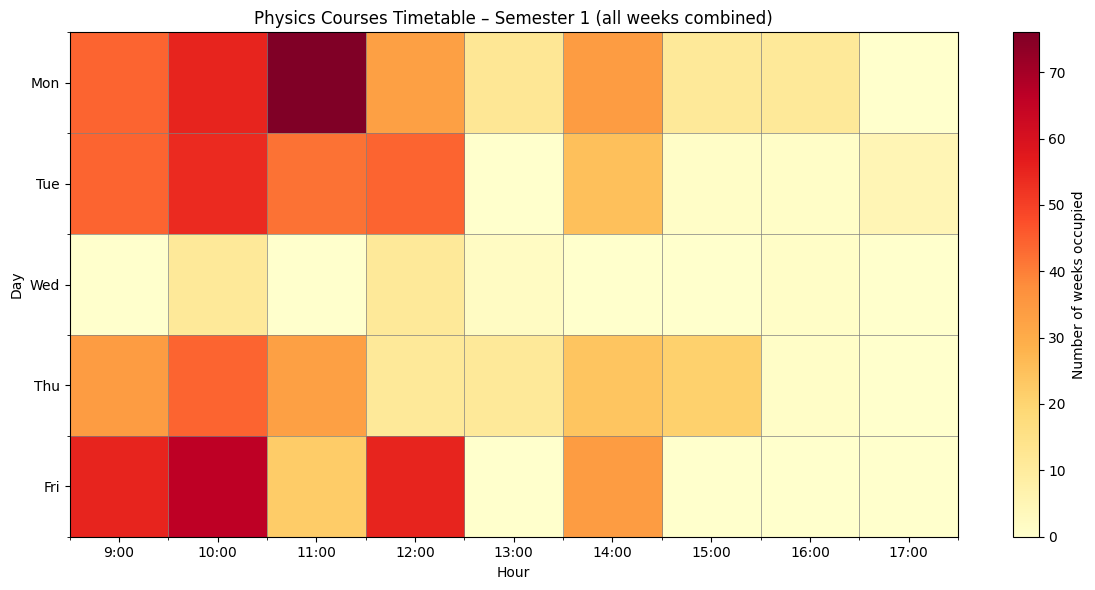

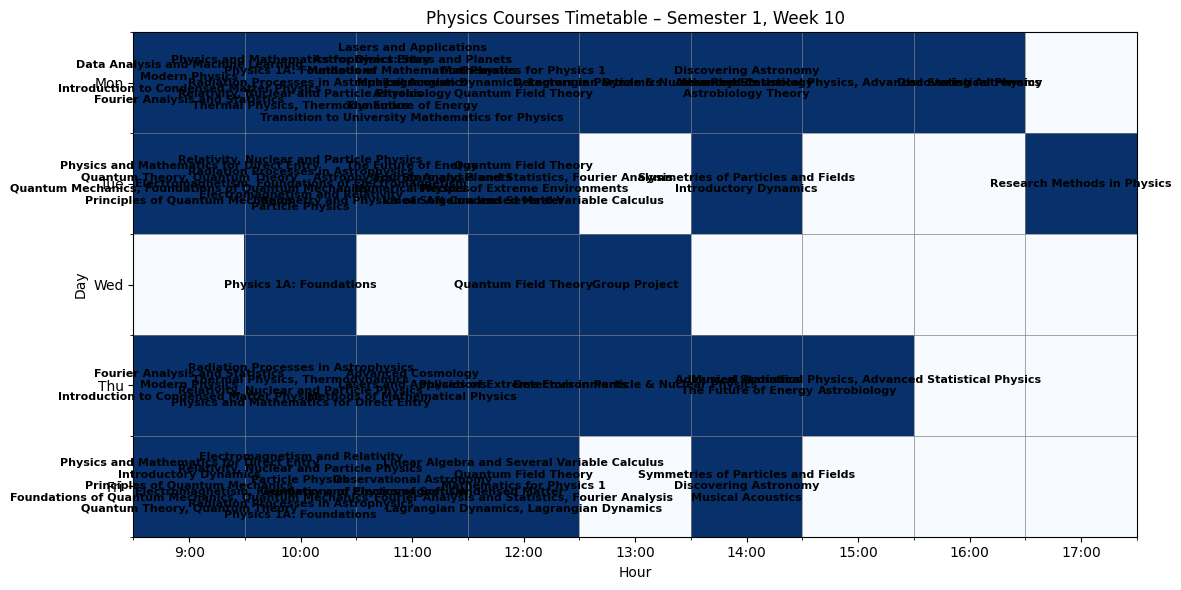

In [15]:
# Plot all physics courses in Semester 1 (all weeks combined)
plot_physics_timetable(courses_df, semester=1, week=None)

# Plot physics courses for Week 10 in Semester 1
plot_physics_timetable(courses_df, semester=1, week=10)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_compulsory_timetable(programme_name, programme_data, courses_df, 
                              semester=1, week=None,
                              day_names=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
                              hour_range=(9, 17),   # 9am to 5pm
                              figsize=(12, 6)):
    """
    Plot the timetable of compulsory courses for a given programme.
    
    Parameters:
    - programme_name: string (e.g., 'Mathematics and Physics (BSc Hons)')
    - programme_data: dictionary returned by extract_programme_structure()
    - courses_df: DataFrame containing course event data
    - semester: 1 or 2
    - week: int (1-52) or None. If None, shows all weeks (heatmap of occupancy count)
    - day_names: list of day labels
    - hour_range: tuple (start_hour, end_hour) in 24h format
    - figsize: figure size
    """
    # Get compulsory courses for the programme
    if programme_name not in programme_data:
        print(f"Programme '{programme_name}' not found in programme data.")
        return
    
    compulsory_courses = programme_data[programme_name]['compulsory_courses']
    if not compulsory_courses:
        print(f"No compulsory courses found for {programme_name}")
        return
    
    print(f"Compulsory courses for {programme_name}: {compulsory_courses}")
    
    # Filter timetable data for these courses
    relevant_df = courses_df[courses_df['Module Name'].isin(compulsory_courses)].copy()
    if relevant_df.empty:
        print("No timetable data found for these courses.")
        return
    
    # Parse timeslot and weeks
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to indices
    day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4,
               'Saturday':5, 'Sunday':6}
    
    # Create grid
    hours = list(range(hour_range[0], hour_range[1]+1))
    n_hours = len(hours)
    n_days = len(day_names)
    
    # Initialize occupancy grid
    if week is None:
        occupancy = np.zeros((n_days, n_hours))   # count of weeks
    else:
        occupancy = np.zeros((n_days, n_hours), dtype=bool)
        labels = [[[] for _ in hours] for _ in day_names]
    
    # Process each row
    for _, row in relevant_df.iterrows():
        # Check semester
        sem = row.get('Semester')
        if isinstance(sem, str):
            if sem == 'Semester 1':
                sem_num = 1
            elif sem == 'Semester 2':
                sem_num = 2
            else:
                continue
        else:
            sem_num = sem
        if sem_num != semester:
            continue
        
        # Parse timeslot
        day_str, hour = parse_timeslot(row['Timeslot'])
        if day_str is None or hour is None:
            continue
        if day_str not in day_map:
            continue
        day_idx = day_map[day_str]
        if day_idx >= n_days:  # only show requested days
            continue
        if hour < hour_range[0] or hour > hour_range[1]:
            continue
        hour_idx = hour - hour_range[0]
        
        # Get weeks
        weeks = parse_weeks(row['Weeks'])
        if not weeks:
            continue
        
        if week is not None:
            if week in weeks:
                occupancy[day_idx, hour_idx] = True
                # Add course name to labels (maybe include course code as well)
                course_name = row['Module Name']
                labels[day_idx][hour_idx].append(course_name)
        else:
            occupancy[day_idx, hour_idx] += len(weeks)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    if week is None:
        im = ax.imshow(occupancy, cmap='YlOrRd', aspect='auto',
                       vmin=0, vmax=occupancy.max() if occupancy.max() > 0 else 1)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of weeks occupied')
    else:
        im = ax.imshow(occupancy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        # Add text labels
        for i in range(n_days):
            for j in range(n_hours):
                if occupancy[i, j]:
                    # Combine course names
                    courses_text = '\n'.join(labels[i][j])
                    ax.text(j, i, courses_text, ha='center', va='center',
                            fontsize=8, color='black', weight='bold')
    
    # Set axes
    ax.set_xticks(range(n_hours))
    ax.set_xticklabels([f'{h}:00' for h in hours])
    ax.set_yticks(range(n_days))
    ax.set_yticklabels(day_names[:n_days])
    ax.set_xlabel('Hour')
    ax.set_ylabel('Day')
    title = f"Compulsory Courses – {programme_name} (Semester {semester})"
    if week:
        title += f", Week {week}"
    else:
        title += " (all weeks combined)"
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_hours, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_days, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

Compulsory courses for Mathematics and Physics (BSc Hons): ['Electromagnetism and Relativity']


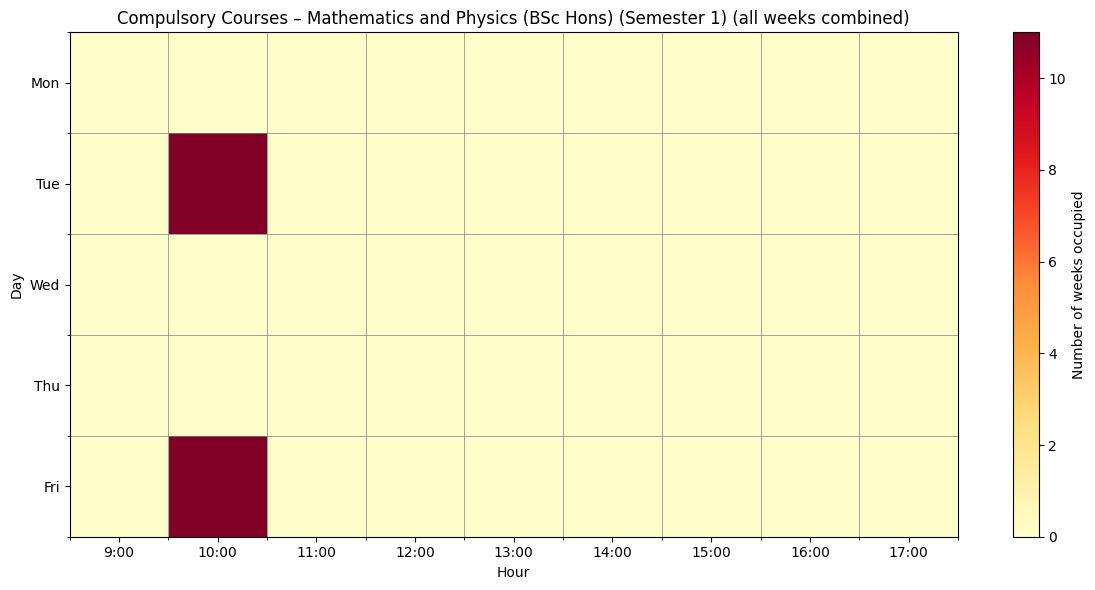

Compulsory courses for Mathematics and Physics (BSc Hons): ['Electromagnetism and Relativity']


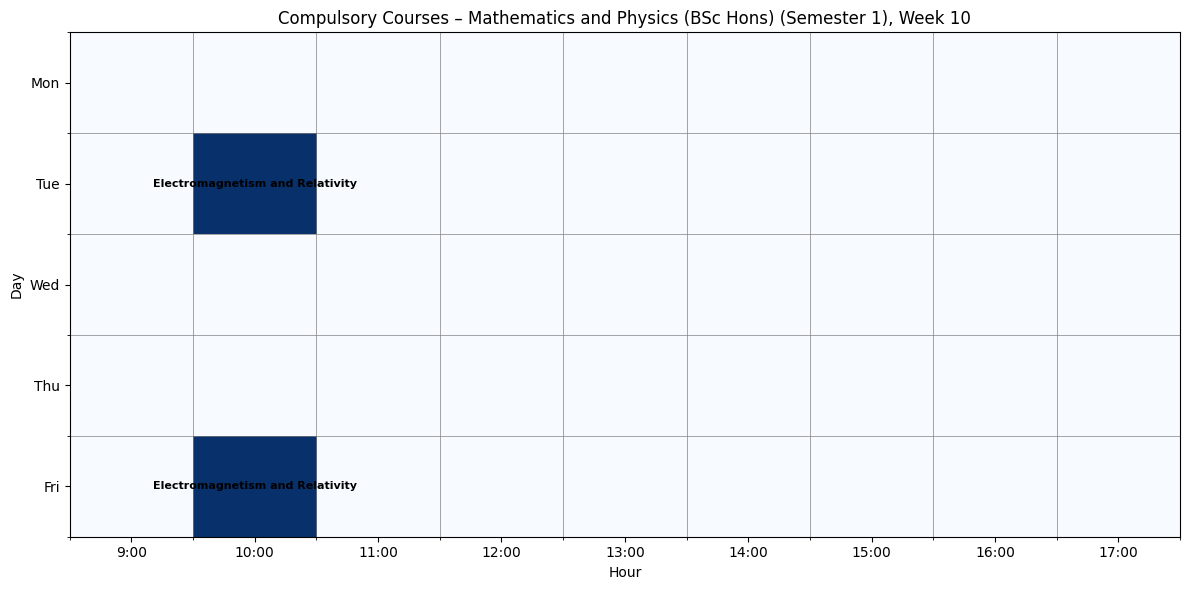

In [17]:
# Plot all weeks for Semester 1
plot_compulsory_timetable('Mathematics and Physics (BSc Hons)', 
                          programme_data, courses_df, 
                          semester=1, week=None)

# Plot a specific week (e.g., week 10)
plot_compulsory_timetable('Mathematics and Physics (BSc Hons)', 
                          programme_data, courses_df, 
                          semester=1, week=10)

In [18]:
courses_df.head()

,Module Department,Module Code,Module Name,Event ID,Event Name,Event Type,Duration (minutes),Event Size,Timeslot,WholeClass,Online Delivery,Number of Weeks,Weeks,Room,Room type 2,Room Type 1,Building,Campus,Semester,Room Lock
4,Business School,BUST10149_SV1_SEM1_2024/5,"Mergers, Acquisitions, and Corporate Restructu...",E:Y2SNRCC5RT,"Mergers, Acquisitions, and Corporate Restructu...",Lecture,110,120.0,Monday 11:00,True,NaN,2,"9, 17",LectureTheatre_ChambersStreetMuseum,General Teaching,Centrally Allocated Space,Hired Space - Contingency,Central,Semester 1,No
9,Business School,CMSE11554_SV1_SB4_2024/5,Marketing of Services,E:AE63FPRPRF,Marketing of Services - Lecture,Lecture,110,50.0,Monday 13:00,True,NaN,4,"32, 33, 34, 35",0226_-1_LG.11,General Teaching,Locally Allocated Space,Business School,Central,Semester 2,No
12,Business School,CMSE11657_SS1_SEM2_2024/5,Topics in Banking Innovation,E:V6NXXE8U85,Topics in Banking Innovation - Lecture,Lecture,110,35.0,Thursday 13:00,True,NaN,4,"28, 29, 30, 32",0226_-1_LG.11,General Teaching,Locally Allocated Space,Business School,Central,Semester 2,No
18,Business School,CMSE11656_SV1_SB3_2024/5,"Strategy, Power & Politics: Navigating to Net ...",E:6NNNGFHDL7,"Strategy, Power & Politics: Navigating to Net ...",Lecture,50,65.0,Thursday 12:00,True,NaN,5,"26, 27, 28, 29, 30",0226_-1_LG.18,General Teaching,Locally Allocated Space,Business School,Central,Semester 2,No
21,Business School,BUST10023_SV1_SEM1_2024/5,Futures and Options,E:HG8QHQ8GZV,Futures and Options - Lecture,Lecture,120,65.0,Thursday 10:00,True,NaN,10,"9, 10, 11, 12, 13, 15, 16, 17, 18, 19",0226_-1_LG.14,General Teaching,Locally Allocated Space,Business School,Central,Semester 1,No
